In [1]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_2_Lexicon_Data.csv")
data.head()

,publish_date,author,Stemmed_Text,Sentiment,Compound_Score
0,2024-06-07 16:26:00,Oleh :\n\n\nDera Fitri,viva usaha homliv anugerah tritunggal indonesi...,Positive,0.021429
1,2021-11-01 23:18:00,"Oleh :\n\n\nFikri Halim,\n ...",viva menteri negeri mendagri tito karnavian te...,Positive,0.039604
2,2021-11-15 09:25:00,Oleh :\n\n\nSyahdan Nurdin,viva rektor universitas widya mataram uwm yogy...,Positive,0.070423
3,2023-03-08 16:11:00,Oleh :\n\n\nDera Fitri,viva senantiasa dorong industri tumbuh ekonomi...,Positive,0.081433
4,2022-05-02 15:51:00,"Oleh :\n\n\nMohammad Arief Hidayat,\n ...",viva presiden joko widodo terima kunjung mente...,Positive,0.093750


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Pastikan kolom 'Stemmed_Text' dan 'Sentiment' ada di dataset
if 'Stemmed_Text' not in data.columns or 'Sentiment' not in data.columns:
    raise ValueError("Kolom 'Stemmed_Text' atau 'Sentiment' tidak ditemukan dalam dataset.")

# Mengubah tipe data 'Sentiment' menjadi category untuk efisiensi
data['Sentiment'] = data['Sentiment'].astype("category")

# Inisialisasi CountVectorizer dengan batasan jumlah fitur
vectorizer = CountVectorizer(max_features=5000)  # Ambil hanya 5000 kata paling sering
X = vectorizer.fit_transform(data['Stemmed_Text'])
features = vectorizer.get_feature_names_out()

# Konversi ke DataFrame menggunakan Sparse DataFrame untuk efisiensi memori
df_tokens = pd.DataFrame.sparse.from_spmatrix(X, columns=features)

# Gabungkan dengan data asli (tanpa menggunakan .toarray() untuk menghindari memori besar)
df_combined = pd.concat([df_tokens, data[['Stemmed_Text', 'Sentiment']]], axis=1)

# Menghitung frekuensi token untuk setiap sentimen
frequency_positive = df_combined[df_combined['Sentiment'] == 'Positive'].drop(columns=['Sentiment', 'Stemmed_Text']).sum()
frequency_negative = df_combined[df_combined['Sentiment'] == 'Negative'].drop(columns=['Sentiment', 'Stemmed_Text']).sum()

# Menghitung probabilitas prior
sentiment_counts = data['Sentiment'].value_counts()
total_samples = len(data)
prior_probabilities = sentiment_counts / total_samples

# Cetak hasil prior probabilities
print("Prior Probabilities:")
print(prior_probabilities)

Prior Probabilities:
Sentiment
Positive    0.626693
Negative    0.373307
Name: count, dtype: float64


In [3]:
# Menghitung probabilitas kondisional dengan smoothing Laplace
total_positive = frequency_positive.sum()
total_negative = frequency_negative.sum()

probability_conditional_positive = (frequency_positive + 1)/(total_positive + len(features))
probability_conditional_negative = (frequency_negative + 1)/(total_negative + len(features))

print("Probability Conditional Positif:")
print(probability_conditional_positive)
print("Probability Conditional Negatif:")
print(probability_conditional_negative)


Probability Conditional Positif:
ab          0.000007
abad        0.000092
abadi       0.000061
abai        0.000028
abang       0.000023
              ...   
zonasi      0.000032
zone         0.00003
zudan        0.00005
zulhas      0.000468
zulkifli    0.000192
Length: 5000, dtype: Sparse[float64, np.float64(2.7610122975487735e-07)]
Probability Conditional Negatif:
ab          0.000061
abad        0.000114
abadi       0.000032
abai        0.000078
abang        0.00003
              ...   
zonasi      0.000048
zone        0.000008
zudan       0.000027
zulhas      0.000317
zulkifli    0.000142
Length: 5000, dtype: Sparse[float64, np.float64(4.68271777447282e-07)]


In [4]:
def calculate_posterior_probabilities(document):
    if not isinstance(document, str):  
        return {'Positif': 1, 'Negatif': 1, 'Neutral': 1}

    words = document.split()
    
    # Ambil prior probabilities, tambahkan smoothing agar tidak 0
    posterior_positive = prior_probabilities.get('Positif', 1e-6)
    posterior_negative = prior_probabilities.get('Negatif', 1e-6)

    for word in words:
        # Tambahkan smoothing untuk menghindari probabilitas nol
        posterior_positive *= probability_conditional_positive.get(word, 1e-6)
        posterior_negative *= probability_conditional_negative.get(word, 1e-6)

    return {
        'Positif': posterior_positive,
        'Negatif': posterior_negative,
    }

data['posterior_probabilities'] = data['Stemmed_Text'].apply(calculate_posterior_probabilities)
data.head()


,publish_date,author,Stemmed_Text,Sentiment,Compound_Score,posterior_probabilities
0,2024-06-07 16:26:00,Oleh :\n\n\nDera Fitri,viva usaha homliv anugerah tritunggal indonesi...,Positive,0.021429,"{'Positif': 0.0, 'Negatif': 0.0}"
1,2021-11-01 23:18:00,"Oleh :\n\n\nFikri Halim,\n ...",viva menteri negeri mendagri tito karnavian te...,Positive,0.039604,"{'Positif': 0.0, 'Negatif': 0.0}"
2,2021-11-15 09:25:00,Oleh :\n\n\nSyahdan Nurdin,viva rektor universitas widya mataram uwm yogy...,Positive,0.070423,"{'Positif': 0.0, 'Negatif': 0.0}"
3,2023-03-08 16:11:00,Oleh :\n\n\nDera Fitri,viva senantiasa dorong industri tumbuh ekonomi...,Positive,0.081433,"{'Positif': 0.0, 'Negatif': 0.0}"
4,2022-05-02 15:51:00,"Oleh :\n\n\nMohammad Arief Hidayat,\n ...",viva presiden joko widodo terima kunjung mente...,Positive,0.093750,"{'Positif': 0.0, 'Negatif': 0.0}"


MultinomialNB Results
Confusion Matrix (MultinomialNB):
[[1063  437]
 [ 447 2071]]

Classification Report (MultinomialNB):
              precision    recall  f1-score   support

    Negative       0.70      0.71      0.71      1500
    Positive       0.83      0.82      0.82      2518

    accuracy                           0.78      4018
   macro avg       0.76      0.77      0.77      4018
weighted avg       0.78      0.78      0.78      4018

Accuracy (MultinomialNB): 0.7800


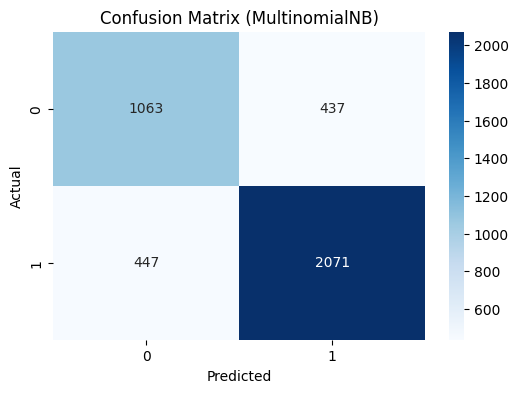

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB  # ⬅️ Lebih cocok untuk TF-IDF
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from scipy.sparse import csr_matrix  # ⬅️ Gunakan Sparse Matrix

# Preprocessing data
tfidf = TfidfVectorizer(max_features=5000)  # ⬅️ Batasi jumlah fitur untuk mengurangi ukuran data
X = tfidf.fit_transform(data['Stemmed_Text'])  # ⬅️ Biarkan sebagai sparse matrix, jangan pakai `.toarray()`
y = data['Sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert to sparse matrix jika masih dalam format dense (Opsional)
X_train = csr_matrix(X_train)
X_test = csr_matrix(X_test)

# Apply SMOTE (hanya bisa untuk dense array, jadi convert dulu)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train.toarray(), y_train)

# Model lebih cocok menggunakan MultinomialNB (Naïve Bayes untuk data teks)
nb = MultinomialNB()
nb.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred_nb = nb.predict(X_test)

# Evaluate
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
class_report_nb = classification_report(y_test, y_pred_nb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("MultinomialNB Results")
print("===================")
print("Confusion Matrix (MultinomialNB):")
print(conf_matrix_nb)
print("====================================")
print("\nClassification Report (MultinomialNB):")
print(class_report_nb)
print("===================================")
print(f"Accuracy (MultinomialNB): {accuracy_nb:.4f}")
print("====================================")

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (MultinomialNB)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


MultinomialNB with Hyperparameter Tuning Results
Best Alpha: 0.5
Confusion Matrix:
[[1064  436]
 [ 446 2072]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.71      0.71      1500
    Positive       0.83      0.82      0.82      2518

    accuracy                           0.78      4018
   macro avg       0.77      0.77      0.77      4018
weighted avg       0.78      0.78      0.78      4018

Accuracy: 0.7805


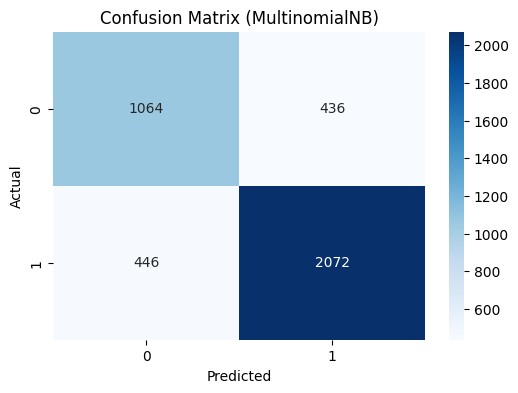

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from scipy.sparse import csr_matrix

# Preprocessing data
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['Stemmed_Text'])
y = data['Sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert ke sparse matrix (Opsional)
X_train = csr_matrix(X_train)
X_test = csr_matrix(X_test)

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train.toarray(), y_train)

# Hyperparameter tuning dengan GridSearchCV
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]}
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

# Gunakan model terbaik
best_nb = grid_search.best_estimator_
y_pred_nb = best_nb.predict(X_test)

# Evaluate
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
class_report_nb = classification_report(y_test, y_pred_nb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("MultinomialNB with Hyperparameter Tuning Results")
print("=================================================")
print(f"Best Alpha: {grid_search.best_params_['alpha']}")
print("Confusion Matrix:")
print(conf_matrix_nb)
print("=================================================")
print("\nClassification Report:")
print(class_report_nb)
print("=================================================")
print(f"Accuracy: {accuracy_nb:.4f}")
print("=================================================")

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (MultinomialNB)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

MultinomialNB with Hyperparameter Tuning Results
Best Alpha: 0.5
Confusion Matrix:
[[ 949  551]
 [ 308 2210]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.63      0.69      1500
    Positive       0.80      0.88      0.84      2518

    accuracy                           0.79      4018
   macro avg       0.78      0.76      0.76      4018
weighted avg       0.78      0.79      0.78      4018

Accuracy: 0.7862


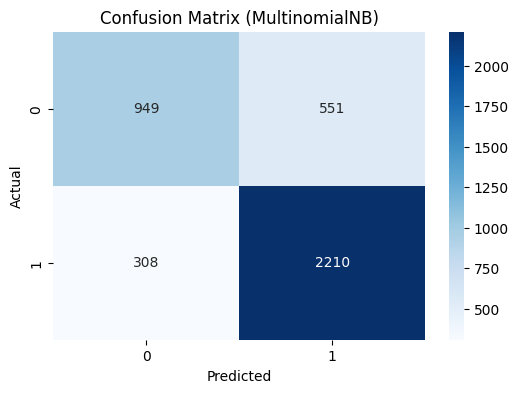

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from scipy.sparse import csr_matrix

# Preprocessing data
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['Stemmed_Text'])
y = data['Sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert ke sparse matrix (Opsional)
X_train = csr_matrix(X_train)
X_test = csr_matrix(X_test)

# Hyperparameter tuning dengan GridSearchCV
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]}
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Gunakan model terbaik
best_nb = grid_search.best_estimator_
y_pred_nb = best_nb.predict(X_test)

# Evaluate
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
class_report_nb = classification_report(y_test, y_pred_nb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("MultinomialNB with Hyperparameter Tuning Results")
print("=================================================")
print(f"Best Alpha: {grid_search.best_params_['alpha']}")
print("Confusion Matrix:")
print(conf_matrix_nb)
print("=================================================")
print("\nClassification Report:")
print(class_report_nb)
print("=================================================")
print(f"Accuracy: {accuracy_nb:.4f}")
print("=================================================")

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (MultinomialNB)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

SVM with Linear Kernel & Hyperparameter Tuning Results
Best C: 10
Confusion Matrix:
[[1326  174]
 [ 175 2343]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      1500
    Positive       0.93      0.93      0.93      2518

    accuracy                           0.91      4018
   macro avg       0.91      0.91      0.91      4018
weighted avg       0.91      0.91      0.91      4018

Accuracy: 0.9131


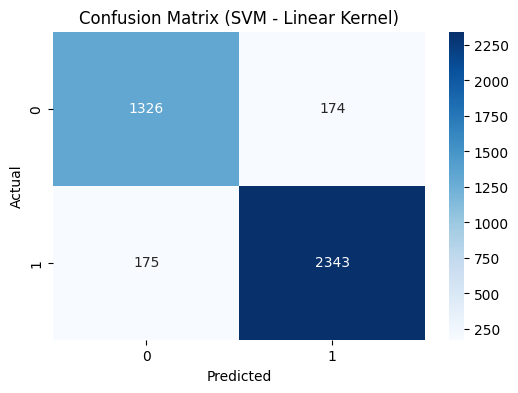

In [8]:
# Dengan menggunakan Hypertuning Gridsearch

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# Preprocessing data
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['Stemmed_Text']).toarray()
y = data['Sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Hyperparameter tuning dengan GridSearchCV untuk kernel linear
param_grid = {
    'C': [0.1, 1, 10, 100]  # C mengontrol margin (regularisasi)
}

grid_search = GridSearchCV(SVC(kernel='linear'), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

# Gunakan model terbaik
best_svm = grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test)

# Evaluate
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM with Linear Kernel & Hyperparameter Tuning Results")
print("=================================================")
print(f"Best C: {grid_search.best_params_['C']}")
print("Confusion Matrix:")
print(conf_matrix_svm)
print("=================================================")
print("\nClassification Report:")
print(class_report_svm)
print("=================================================")
print(f"Accuracy: {accuracy_svm:.4f}")
print("=================================================")

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SVM - Linear Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

SVM with RBF Kernel & Hyperparameter Tuning Results
Best Parameters: {'C': 100, 'gamma': 0.1}
Confusion Matrix:
[[1311  189]
 [ 160 2358]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      1500
    Positive       0.93      0.94      0.93      2518

    accuracy                           0.91      4018
   macro avg       0.91      0.91      0.91      4018
weighted avg       0.91      0.91      0.91      4018

Accuracy: 0.9131


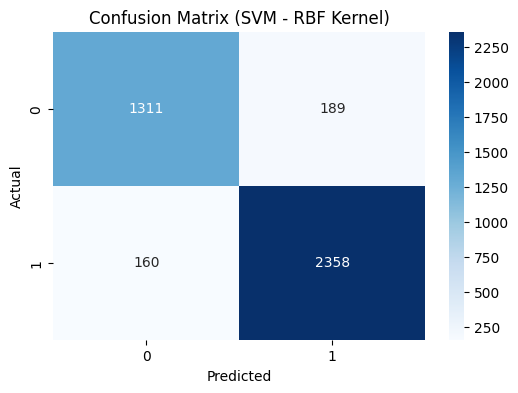

In [9]:
# Dengan menggunakan Hypertuning Gridsearch

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# Preprocessing data
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['Stemmed_Text']).toarray()
y = data['Sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Hyperparameter tuning dengan GridSearchCV untuk kernel RBF
param_grid = {
    'C': [1, 10, 100],  # Kurangi jumlah nilai C
    'gamma': ['scale', 0.1]  # Kurangi jumlah nilai gamma
}

grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

# Gunakan model terbaik
best_svm = grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test)

# Evaluate
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM with RBF Kernel & Hyperparameter Tuning Results")
print("=================================================")
print(f"Best Parameters: {grid_search.best_params_}")
print("Confusion Matrix:")
print(conf_matrix_svm)
print("=================================================")
print("\nClassification Report:")
print(class_report_svm)
print("=================================================")
print(f"Accuracy: {accuracy_svm:.4f}")
print("=================================================")

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SVM - RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Fitting 3 folds for each of 24 candidates, totalling 72 fits

SVM dengan Kernel Polynomial & Hypertuning GridSearchCV (Optimized)
Best Parameters: {'C': 10, 'coef0': 0.5, 'degree': 2, 'gamma': 'scale'}
Confusion Matrix:
[[1289  211]
 [ 171 2347]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      1500
    Positive       0.92      0.93      0.92      2518

    accuracy                           0.90      4018
   macro avg       0.90      0.90      0.90      4018
weighted avg       0.90      0.90      0.90      4018

Accuracy: 0.9049


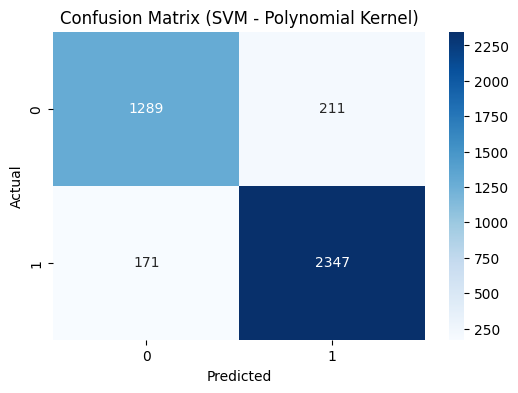

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE


# **2️⃣ Preprocessing: TF-IDF Vectorization**
tfidf = TfidfVectorizer(max_features=5000)  # Batasi fitur agar lebih cepat
X = tfidf.fit_transform(data['Stemmed_Text']).toarray()
y = data['Sentiment']

# **3️⃣ Split Data untuk Training & Testing**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **4️⃣ Gunakan SMOTE untuk Mengatasi Class Imbalance**
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# **5️⃣ Gunakan Hanya 10.000 Data untuk GridSearchCV (Agar Lebih Cepat)**
X_sample, y_sample = X_train_resampled[:10000], y_train_resampled[:10000]

# **6️⃣ Hyperparameter Tuning dengan GridSearchCV (Optimized)**
param_grid = {
    'C': [0.1, 1, 10],          # Regularisasi (batasi ke 3 nilai)
    'degree': [2, 3],           # Batasi ke polynomial rendah
    'gamma': ['scale', 0.1],    # Gunakan default dan angka kecil
    'coef0': [0, 0.5]           # Gunakan 2 nilai untuk efisiensi
}

# **Model SVM dengan kernel polynomial**
svm_model = SVC(kernel='poly')

# **GridSearchCV dengan optimasi**
grid_search = GridSearchCV(
    svm_model, param_grid, 
    cv=3,  # Kurangi ke 3 fold agar lebih cepat
    scoring='accuracy',
    n_jobs=-1,  # Gunakan semua core CPU
    verbose=2
)

# **7️⃣ Training GridSearchCV pada Subset Data**
grid_search.fit(X_sample, y_sample)

# **8️⃣ Ambil Model Terbaik & Latih pada Full Dataset**
best_svm = grid_search.best_estimator_
best_svm.fit(X_train_resampled, y_train_resampled)

# **9️⃣ Prediksi pada Test Set**
y_pred_svm = best_svm.predict(X_test)

# **🔟 Evaluasi Model**
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# **🔹 Print Hasil**
print("\nSVM dengan Kernel Polynomial & Hypertuning GridSearchCV (Optimized)")
print("=================================================")
print(f"Best Parameters: {grid_search.best_params_}")
print("Confusion Matrix:")
print(conf_matrix_svm)
print("=================================================")
print("\nClassification Report:")
print(class_report_svm)
print("=================================================")
print(f"Accuracy: {accuracy_svm:.4f}")
print("=================================================")

# **🔹 Plot Confusion Matrix**
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SVM - Polynomial Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Fitting 3 folds for each of 27 candidates, totalling 81 fits

SVM dengan Kernel Sigmoid & GridSearchCV (Optimized)
Best Parameters: {'C': 10, 'coef0': 0, 'gamma': 0.1}
Confusion Matrix:
[[1334  166]
 [ 248 2270]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.87      1500
    Positive       0.93      0.90      0.92      2518

    accuracy                           0.90      4018
   macro avg       0.89      0.90      0.89      4018
weighted avg       0.90      0.90      0.90      4018

Accuracy: 0.8970


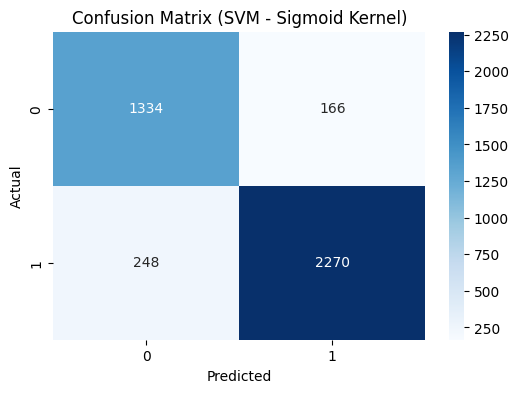

In [12]:
# Dengan menggunakan Hypertuning Gridsearch

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE


# **2️⃣ Preprocessing: TF-IDF Vectorization**
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['Stemmed_Text']).toarray()
y = data['Sentiment']

# **3️⃣ Split Data untuk Training & Testing**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **4️⃣ Gunakan SMOTE untuk Mengatasi Class Imbalance**
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# **5️⃣ Gunakan Hanya 10.000 Data untuk GridSearchCV (Agar Lebih Cepat)**
X_sample, y_sample = X_train_resampled[:10000], y_train_resampled[:10000]

# **6️⃣ Hyperparameter Tuning dengan GridSearchCV untuk Kernel Sigmoid**
param_grid = {
    'C': [0.1, 1, 10],         # Regularisasi
    'gamma': ['scale', 0.1, 1], # Parameter kernel
    'coef0': [0, 0.5, 1]        # Bias dalam kernel sigmoid
}

svm_model = SVC(kernel='sigmoid')

grid_search = GridSearchCV(
    svm_model, param_grid, 
    cv=3, scoring='accuracy',
    n_jobs=-1, verbose=2
)

# **7️⃣ Training GridSearchCV pada Subset Data**
grid_search.fit(X_sample, y_sample)

# **8️⃣ Ambil Model Terbaik & Latih pada Full Dataset**
best_svm = grid_search.best_estimator_
best_svm.fit(X_train_resampled, y_train_resampled)

# **9️⃣ Prediksi pada Test Set**
y_pred_svm = best_svm.predict(X_test)

# **🔟 Evaluasi Model**
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# **🔹 Print Hasil**
print("\nSVM dengan Kernel Sigmoid & GridSearchCV (Optimized)")
print("=================================================")
print(f"Best Parameters: {grid_search.best_params_}")
print("Confusion Matrix:")
print(conf_matrix_svm)
print("=================================================")
print("\nClassification Report:")
print(class_report_svm)
print("=================================================")
print(f"Accuracy: {accuracy_svm:.4f}")
print("=================================================")

# **🔹 Plot Confusion Matrix**
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SVM - Sigmoid Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()